# Instructor Effectiveness Modeling (EdTech Context)

Role: Data Science / AI Content Specialist Intern
Goal: Analyze batch-level course data, define instructor effectiveness, and build an ML model to predict instructor effectiveness tiers.

Libraries used: pandas, numpy, scikit-learn, matplotlib, seaborn (no LLMs, no external datasets, no AutoML tools).

Note: There is no single correct answer here. All assumptions and design choices are explained inline as we go.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load the Data

Each row is one course batch. An instructor may appear in many rows (multiple batches, possibly across different courses).

In [10]:
import os
csv_files = [f for f in os.listdir() if f.lower().endswith('.csv')]
print("Found CSV:", csv_files)

df = pd.read_csv(csv_files[0])
print("Shape:", df.shape)
df.head()

Found CSV: ['instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv']
Shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [12]:
# Missing values and basic sanity checks
print("Missing values per column:")
print(df.isna().sum())

print("\nUnique batches:", df['batch_id'].nunique())
print("Unique instructors:", df['instructor_id'].nunique())
print("Unique courses:", df['course_id'].nunique())

print("\nBatches per instructor (summary):")
print(df['instructor_id'].value_counts().describe())

Missing values per column:
batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

Unique batches: 2000
Unique instructors: 120
Unique courses: 25

Batches per instructor (summary):
count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: count, dtype: float64


Early observations:
- No missing values in any column — the dataset is already clean.
- 2000 batches, taught by 120 distinct instructors, across 25 distinct courses.
- Instructors teach anywhere from 7 to 31 batches each (mean ≈ 16.7), so every instructor has a reasonably large sample.

## Step 1: Exploratory Data Analysis (EDA)

In [13]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


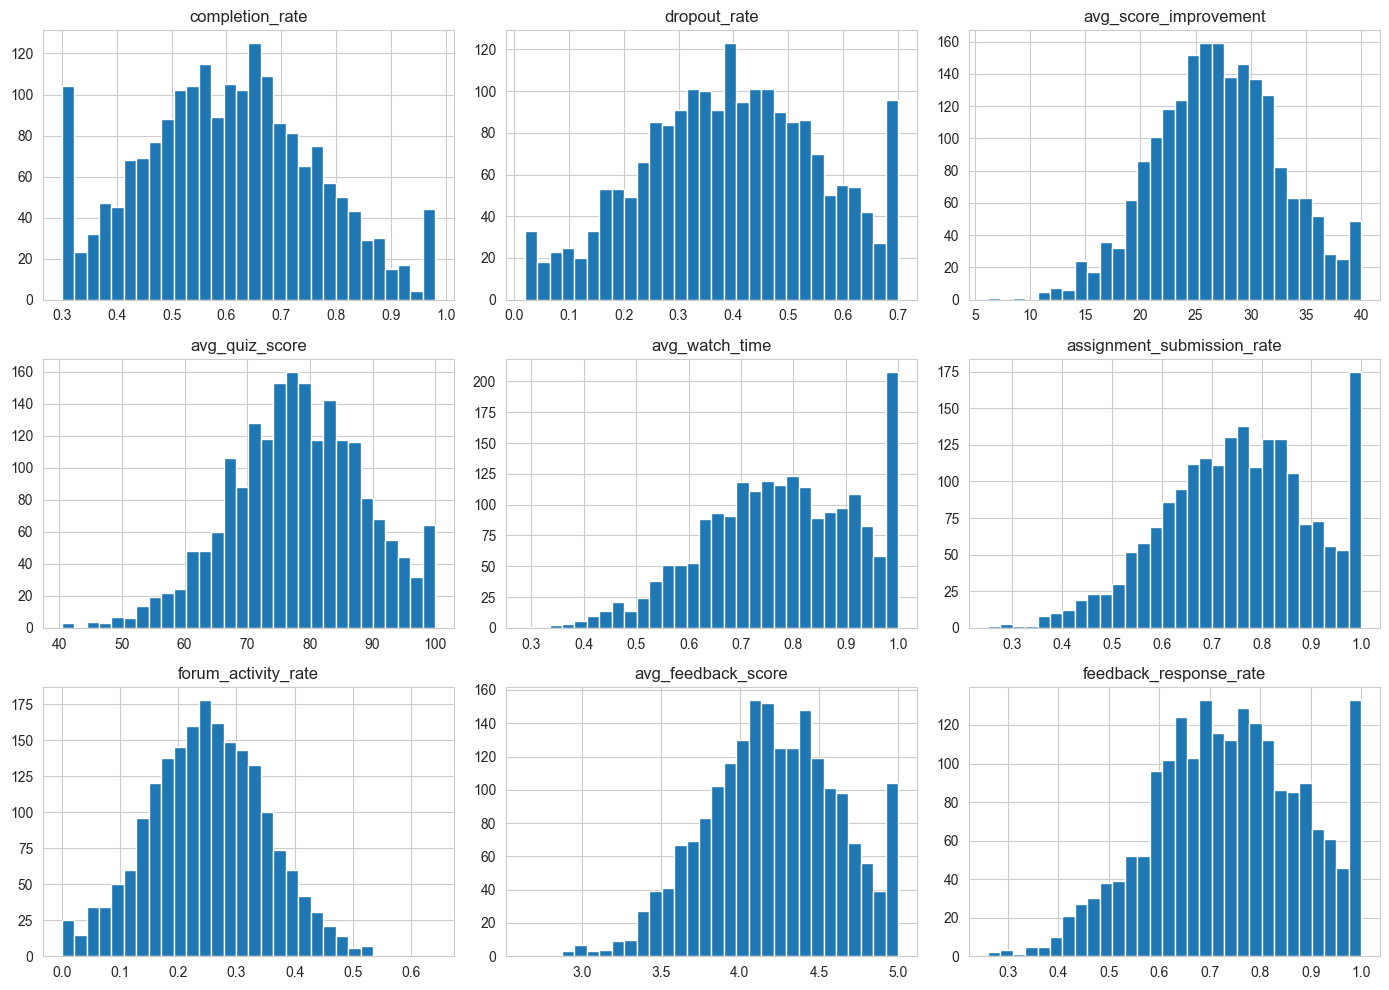

In [14]:
numeric_cols = ['completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score',
                'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
                'avg_feedback_score', 'feedback_response_rate']

df[numeric_cols].hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

Observations on distributions:
- completion_rate and dropout_rate are both clipped at the ends (floor 0.3 / ceiling 0.7), suggesting bounded data generation.
- avg_quiz_score and avg_score_improvement look roughly bell-shaped / mildly right-skewed.
- avg_feedback_score is left-skewed with a cap at 5.
- Rate-like columns are all bounded in [0,1] as documented.

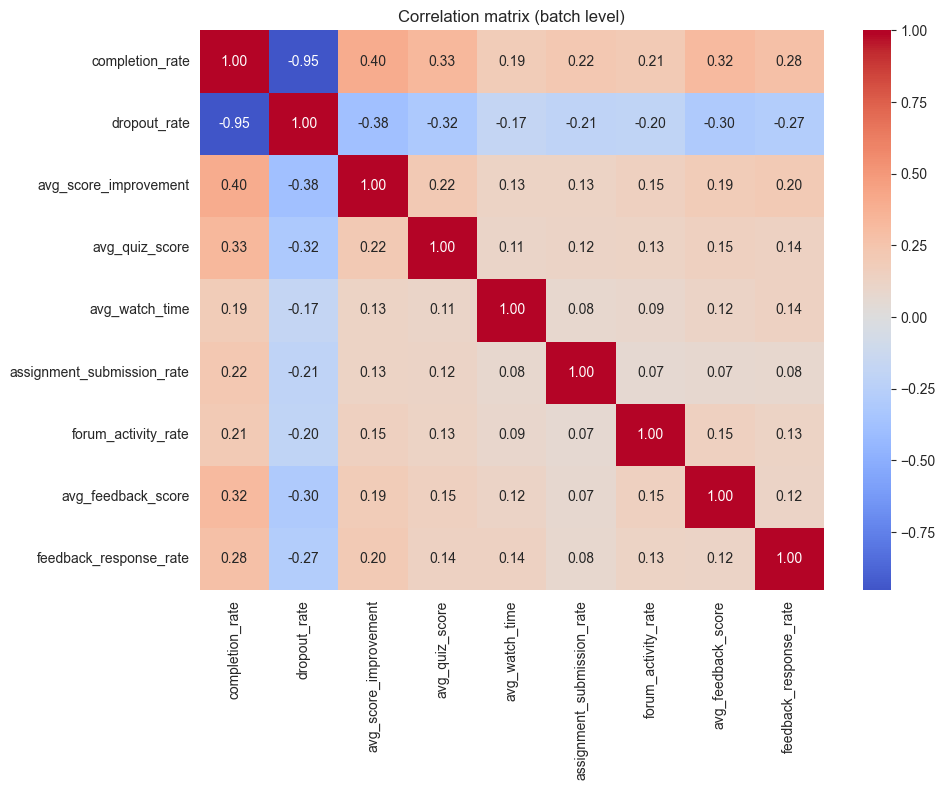

In [15]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (batch level)')
plt.tight_layout()
plt.show()

Key correlations:
- completion_rate and dropout_rate are almost perfectly negatively correlated (≈ -0.95) — redundant information, avoid double-counting.
- completion_rate correlates moderately with avg_score_improvement (~0.40), avg_quiz_score (~0.33), avg_feedback_score (~0.32).
- Engagement metrics correlate positively with outcomes but more weakly (~0.19–0.22).

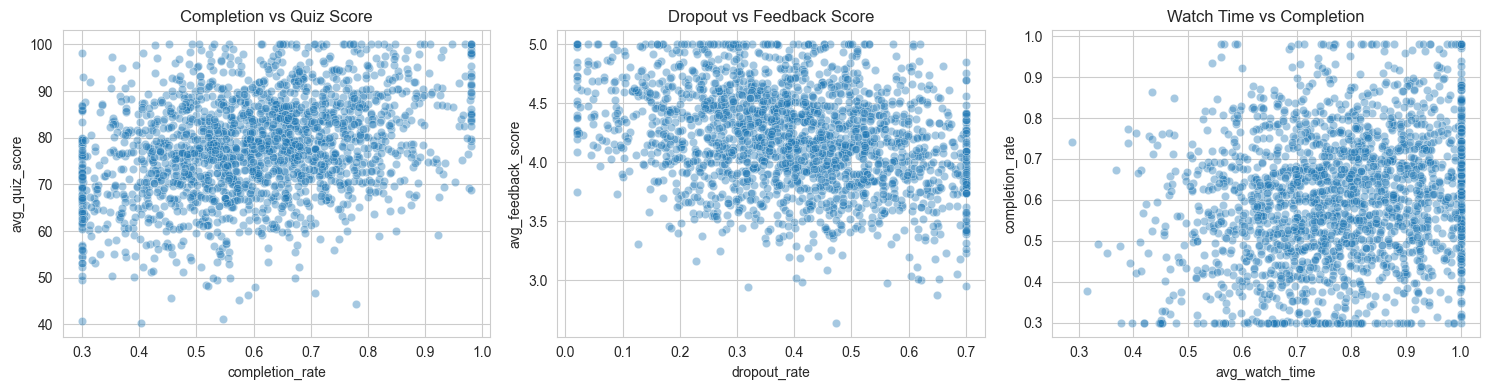

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='completion_rate', y='avg_quiz_score', ax=axes[0], alpha=0.4)
sns.scatterplot(data=df, x='dropout_rate', y='avg_feedback_score', ax=axes[1], alpha=0.4)
sns.scatterplot(data=df, x='avg_watch_time', y='completion_rate', ax=axes[2], alpha=0.4)
axes[0].set_title('Completion vs Quiz Score')
axes[1].set_title('Dropout vs Feedback Score')
axes[2].set_title('Watch Time vs Completion')
plt.tight_layout()
plt.show()

        n_batches   n_courses
count  120.000000  120.000000
mean    16.666667   12.183333
std      4.582270    2.599235
min      7.000000    6.000000
25%     13.750000   10.000000
50%     17.000000   12.000000
75%     19.000000   14.000000
max     31.000000   19.000000


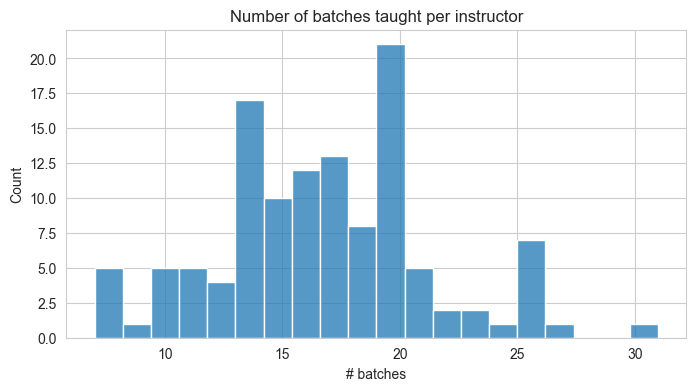

In [17]:
# How many batches does each instructor teach, and how many distinct courses?
batches_per_instr = df.groupby('instructor_id').agg(
    n_batches=('batch_id', 'count'),
    n_courses=('course_id', 'nunique')
)
print(batches_per_instr.describe())

plt.figure(figsize=(8, 4))
sns.histplot(batches_per_instr['n_batches'], bins=20)
plt.title('Number of batches taught per instructor')
plt.xlabel('# batches')
plt.show()

Early observations (summary):
1. No missing data / no obvious anomalies.
2. completion_rate ≈ 1 - dropout_rate — redundant signal.
3. Outcomes, engagement, feedback form three loosely-correlated groups → motivates grouped composite score.
4. Instructors have 7–31 batches; still apply shrinkage for fairness.
5. Most instructors teach multiple courses.

## Step 2: Define Instructor Effectiveness

 There is no predefined formula — this is our own definition, justified below.

### Our definition

We treat "effectiveness" as a weighted composite of three underlying dimensions:

| Dimension | Features used | Weight | Why |
|---|---|---|---|
| Learner Outcomes | completion_rate, 1-dropout_rate, avg_score_improvement (scaled), avg_quiz_score (scaled) | 45% | Most direct evidence learners finished and learned. |
| Engagement | avg_watch_time, assignment_submission_rate, forum_activity_rate | 30% | Leading indicator of outcomes; reflects instructor's ability to keep learners involved. |
| Feedback | avg_feedback_score (scaled), feedback_response_rate | 25% | Direct sentiment, weighted less due to self-report bias. |

We use 1 - dropout_rate instead of both raw columns since they're near-perfectly anti-correlated.

Scaling before combining:
- avg_score_improvement / 40
- avg_quiz_score / 100
- (avg_feedback_score - 1) / 4
- others already in [0,1]

Formula (batch level):
\\\
outcomes   = mean(completion_rate, 1-dropout_rate, avg_score_improvement/40, avg_quiz_score/100)
engagement = mean(avg_watch_time, assignment_submission_rate, forum_activity_rate)
feedback   = mean((avg_feedback_score-1)/4, feedback_response_rate)

batch_effectiveness_score = 0.45*outcomes + 0.30*engagement + 0.25*feedback
\\\

In [18]:
d = df.copy()

# --- Scale raw features to comparable [0,1] ranges ---
d['avg_score_improvement_norm'] = d['avg_score_improvement'] / 40.0
d['avg_quiz_score_norm'] = d['avg_quiz_score'] / 100.0
d['avg_feedback_score_norm'] = (d['avg_feedback_score'] - 1) / 4.0
d['retention_rate'] = 1 - d['dropout_rate']

# --- Build the three sub-dimensions ---
outcomes_cols   = ['completion_rate', 'retention_rate', 'avg_score_improvement_norm', 'avg_quiz_score_norm']
engagement_cols = ['avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate']
feedback_cols   = ['avg_feedback_score_norm', 'feedback_response_rate']

d['outcomes_score']   = d[outcomes_cols].mean(axis=1)
d['engagement_score'] = d[engagement_cols].mean(axis=1)
d['feedback_score']   = d[feedback_cols].mean(axis=1)

# --- Weighted composite (batch level) ---
W_OUTCOMES, W_ENGAGEMENT, W_FEEDBACK = 0.45, 0.30, 0.25
d['batch_effectiveness_score'] = (
    W_OUTCOMES * d['outcomes_score'] +
    W_ENGAGEMENT * d['engagement_score'] +
    W_FEEDBACK * d['feedback_score']
)

d['batch_effectiveness_score'].describe()

count    2000.000000
mean        0.669919
std         0.076249
min         0.396173
25%         0.617526
50%         0.671073
75%         0.719560
max         0.903472
Name: batch_effectiveness_score, dtype: float64

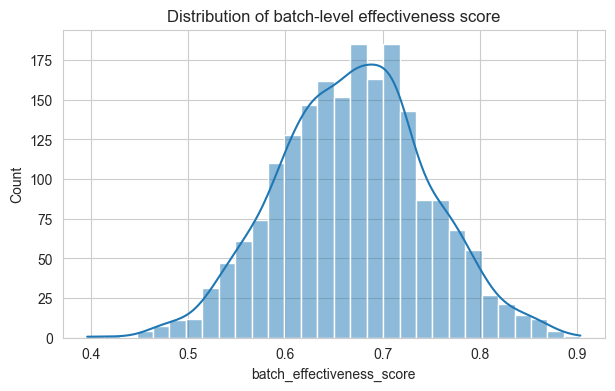

In [19]:
plt.figure(figsize=(7,4))
sns.histplot(d['batch_effectiveness_score'], bins=30, kde=True)
plt.title('Distribution of batch-level effectiveness score')
plt.show()

## Step 3: Aggregate Batch Data to Instructor Level

- Rate/score features → mean per instructor.
- n_batches, n_courses kept as model features/context, not effectiveness signals.
- score_std per instructor = consistency signal.

### Handling instructors with few vs. many batches

Apply shrinkage (partial pooling) toward overall mean:
\\\
instructor_effectiveness_score = (n_batches * raw_mean_score + k * overall_mean) / (n_batches + k)
\\\
Few-batch instructors get pulled more toward the average; many-batch instructors barely adjusted. We use k=5.

In [20]:
agg = d.groupby('instructor_id').agg(
    n_batches=('batch_id', 'count'),
    n_courses=('course_id', 'nunique'),
    completion_rate=('completion_rate', 'mean'),
    dropout_rate=('dropout_rate', 'mean'),
    avg_score_improvement=('avg_score_improvement', 'mean'),
    avg_quiz_score=('avg_quiz_score', 'mean'),
    avg_watch_time=('avg_watch_time', 'mean'),
    assignment_submission_rate=('assignment_submission_rate', 'mean'),
    forum_activity_rate=('forum_activity_rate', 'mean'),
    avg_feedback_score=('avg_feedback_score', 'mean'),
    feedback_response_rate=('feedback_response_rate', 'mean'),
    score_std=('batch_effectiveness_score', 'std'),
    raw_effectiveness_score=('batch_effectiveness_score', 'mean'),
).reset_index()

agg['score_std'] = agg['score_std'].fillna(0)

# --- Shrinkage toward overall mean, weighted by n_batches ---
overall_mean = agg['raw_effectiveness_score'].mean()
K = 5
agg['instructor_effectiveness_score'] = (
    (agg['n_batches'] * agg['raw_effectiveness_score'] + K * overall_mean) / (agg['n_batches'] + K)
)

print("Instructor-level table shape:", agg.shape)
agg.sort_values('instructor_effectiveness_score', ascending=False).head(10)

Instructor-level table shape: (120, 15)


,instructor_id,n_batches,n_courses,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,score_std,raw_effectiveness_score,instructor_effectiveness_score
9,I_010,13,10,0.940783,0.068522,34.856747,90.656473,0.900853,0.837532,0.343266,4.552640,0.891873,0.033930,0.841322,0.793569
36,I_037,15,12,0.923555,0.086773,34.173442,87.282865,0.903739,0.808203,0.327316,4.532852,0.859106,0.033631,0.822660,0.784347
104,I_105,16,12,0.863880,0.141051,33.871306,86.272878,0.870686,0.823636,0.317997,4.507488,0.834154,0.036459,0.801248,0.769859
17,I_018,14,11,0.867026,0.143953,32.225336,89.096936,0.882547,0.850893,0.341459,4.635637,0.781723,0.052469,0.803532,0.768237
4,I_005,19,13,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.045082,0.784891,0.760832
117,I_118,19,14,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,0.050000,0.780354,0.757241
24,I_025,19,14,0.822837,0.163828,31.296431,83.375514,0.860510,0.791487,0.293109,4.374507,0.831763,0.040246,0.772391,0.750937
50,I_051,26,15,0.793270,0.210509,31.353379,84.137118,0.796738,0.823331,0.296151,4.479606,0.789660,0.044986,0.759963,0.745358
90,I_091,8,7,0.897119,0.116080,33.376943,85.028412,0.773583,0.924766,0.264921,4.490270,0.777573,0.039794,0.792491,0.745152
14,I_015,17,11,0.780741,0.238809,31.364753,79.832706,0.867078,0.855627,0.285056,4.521249,0.777381,0.034855,0.759480,0.739010


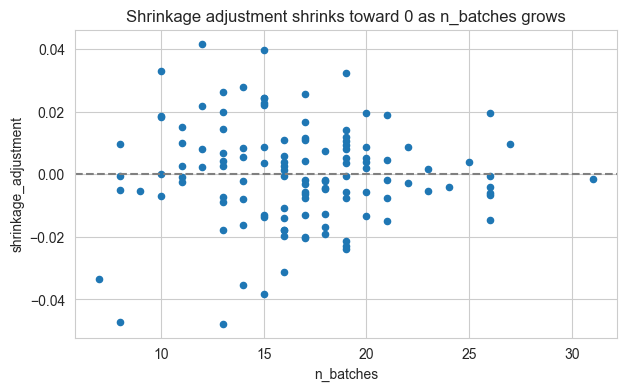

In [21]:
# Sanity check: shrinkage effect should be larger for instructors with fewer batches
agg['shrinkage_adjustment'] = agg['instructor_effectiveness_score'] - agg['raw_effectiveness_score']
agg.plot.scatter(x='n_batches', y='shrinkage_adjustment', figsize=(7,4),
                  title='Shrinkage adjustment shrinks toward 0 as n_batches grows')
plt.axhline(0, color='grey', linestyle='--')
plt.show()

### Converting the score into tiers

We convert the continuous score into Low / Medium / High using tertiles (33rd/67th percentile) — data-driven, roughly balanced classes for model training.

In [22]:
q1, q2 = agg['instructor_effectiveness_score'].quantile([1/3, 2/3])
print(f"Tertile cutoffs: Low <= {q1:.3f} < Medium <= {q2:.3f} < High")

def tier(x):
    if x <= q1:
        return 'Low'
    elif x <= q2:
        return 'Medium'
    else:
        return 'High'

agg['effectiveness_tier'] = agg['instructor_effectiveness_score'].apply(tier)
agg['effectiveness_tier'].value_counts()

Tertile cutoffs: Low <= 0.651 < Medium <= 0.689 < High


effectiveness_tier
Low       40
High      40
Medium    40
Name: count, dtype: int64

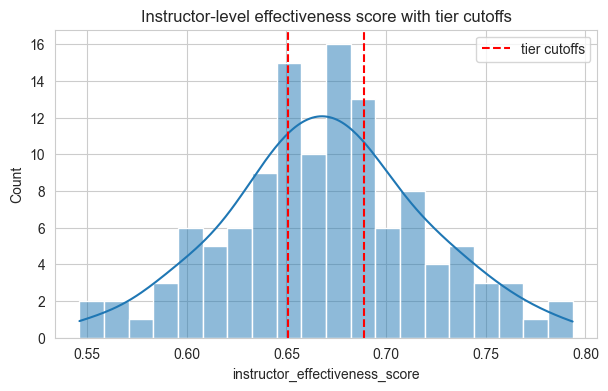

In [23]:
plt.figure(figsize=(7,4))
sns.histplot(agg['instructor_effectiveness_score'], bins=20, kde=True)
plt.axvline(q1, color='red', linestyle='--', label='tier cutoffs')
plt.axvline(q2, color='red', linestyle='--')
plt.legend()
plt.title('Instructor-level effectiveness score with tier cutoffs')
plt.show()

## Step 4: Build a Machine Learning Model

Target: effectiveness_tier at instructor level.

Model choice: Random Forest — handles non-linearities, gives free feature importances, robust on 120-row dataset. Model choice matters less than reasoning.

Features: raw instructor-level aggregates + n_batches, n_courses, score_std. Note: since tiers are derived from these same features, expect strong fit (a form of leakage discussed in mandatory questions).

In [24]:
feature_cols = ['completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score',
                'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
                'avg_feedback_score', 'feedback_response_rate', 'n_batches', 'n_courses', 'score_std']

X = agg[feature_cols]
y = agg['effectiveness_tier']

print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

effectiveness_tier
Low       40
High      40
Medium    40
Name: count, dtype: int64
Train size: (90, 12)  Test size: (30, 12)


In [25]:
# Feature scaling is optional for tree-based models, but done anyway for consistency
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,          # keep shallow to reduce overfitting on small dataset
    class_weight='balanced',
    random_state=RANDOM_STATE
)
clf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

## Step 5: Evaluate the Model

Accuracy is not the primary metric. We lean on macro-F1 and the confusion matrix to check for systematic confusion between adjacent tiers.

In [26]:
y_pred = clf.predict(X_test_scaled)

print(classification_report(y_test, y_pred, digits=3))
print("Macro F1 score:", round(f1_score(y_test, y_pred, average='macro'), 3))

              precision    recall  f1-score   support

        High      1.000     0.900     0.947        10
         Low      1.000     1.000     1.000        10
      Medium      0.909     1.000     0.952        10

    accuracy                          0.967        30
   macro avg      0.970     0.967     0.967        30
weighted avg      0.970     0.967     0.967        30

Macro F1 score: 0.967


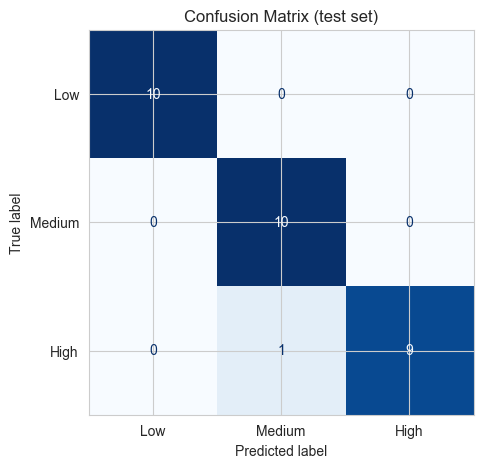

In [27]:
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (test set)')
plt.show()

Trade-offs — precision vs. recall:
- False negative (High → predicted Medium/Low): strong instructor not recognized.
- False positive (Low → predicted Medium/High): weak instructor not flagged for support.
- Tune thresholds based on which error matters more in deployment.

Class imbalance: tertile split keeps classes balanced; class_weight='balanced' used as safety net; macro-F1 reported instead of relying on accuracy alone.

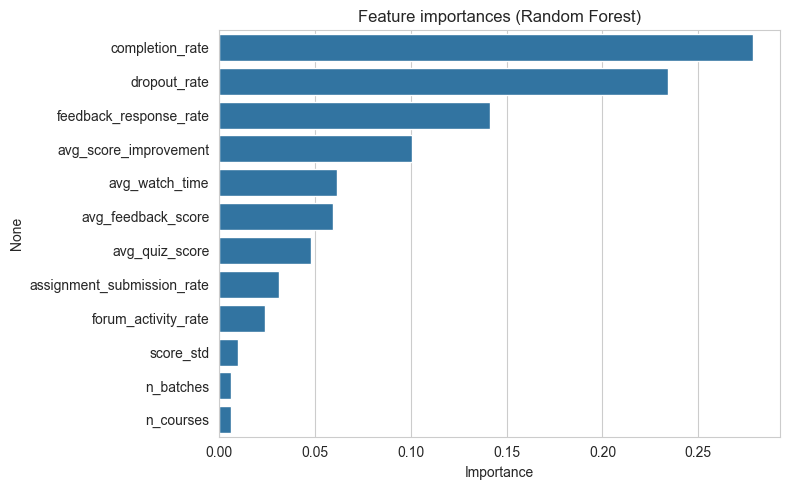

completion_rate               0.278713
dropout_rate                  0.234065
feedback_response_rate        0.141100
avg_score_improvement         0.100400
avg_watch_time                0.061277
avg_feedback_score            0.059360
avg_quiz_score                0.047837
assignment_submission_rate    0.031142
forum_activity_rate           0.024035
score_std                     0.009756
n_batches                     0.006169
n_courses                     0.006147
dtype: float64

In [28]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, orient='h')
plt.title('Feature importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importances

## Step 6: Interpret the Results

In simple terms: Higher completion rates and lower dropout rates are the strongest predictors of "High effectiveness." Feedback response rate and score improvement also matter. Engagement metrics contribute less strongly.

EdTech product use:
- Instructor effectiveness dashboard flagging "Low" tier early for coaching.
- Input into recognition/rewards programs (not sole basis).
- Route "High" tier instructors to mentor others.
- Not for high-stakes decisions alone.

## 5. Mandatory Analysis Questions

### 1. Which features most influenced instructor effectiveness, and why?
completion_rate and dropout_rate dominate, followed by feedback_response_rate and avg_score_improvement — expected since outcomes carry 45% of our score's weight, so the model largely reconstructs our own formula.

### 2. Which variables could be misleading or confounded?
- completion_rate vs dropout_rate: same signal counted twice risk.
- avg_feedback_score/feedback_response_rate: self-selected, biased sample.
- course_id (not used as feature): instructor effectiveness may be confounded by course difficulty.
- n_batches/n_courses: instructors given more batches may already be "trusted" — selection bias.

### 3. How could this model fail in real-world usage?
- Circularity/leakage since label is derived from same features.
- Distribution shift over time.
- Small sample noise for low-batch instructors.
- Gaming the metric once drivers are known.
- Course confounding penalizing instructors on harder courses.

### 4. What additional data would you want to improve this analysis?
- Course difficulty metadata, learner demographics, time trends, qualitative feedback text, peer/manager ratings, instructor tenure.

### 5. Should this model be used for instructor performance evaluation? Why or why not?
Not alone for high-stakes decisions — useful as a screening/triage tool only, since the label is a subjective construction, inputs are confounded, and the near-circular relationship inflates apparent performance.

## 6. Constraints & Guidelines — checklist

-  No LLMs or external APIs used
-  No external datasets used
-  Focus on clarity and reasoning throughout
-  Notebook is reproducible (fixed random_state, deterministic tertile cutoffs)
-  Code and decisions are commented

## 9. Final Note

This notebook favors a simple, transparent, well-justified approach over a maximally complex one.